# Kappa ensemble under the 2026-09-10 production configuration: the forward legs

Eight 10-year forward legs from the 2× spin-up's year-170 pickup (30983, iteration 2986560) under the production configuration decided on 2026-09-10: reference viscosity files, `viscAhReMax=2.`, the flux-limited DST3 scheme 33 with **explicit** vertical tracer advection, GM on. Each leg sets `diffKrT = diffKrS` to its member's κ_v and writes the year-180 pickup its 5-yr adjoint reads (`input/variants/kappa_v_ensemble/data_{REF,M1..M7}_ReMax2`).

| member | κ_v [m² s⁻¹] | × reference | forward leg | adjoint |
| --- | --- | --- | --- | --- |
| REF | 1.2e-5 | 1 | 31205 | 31206 |
| M1 | 3.0e-6 | 0.25 | 31207 | 31208 |
| M2 | 6.0e-6 | 0.5 | 31209 | 31210 |
| M3 | 2.4e-5 | 2 | 31211 | 31212 |
| M4 | 4.8e-5 | 4 | 31213 | 31214 |
| M5 | 9.6e-5 | 8 | 31215 | 31216 |
| M6 | 1.92e-4 | 16 | 31217 | 31218 |
| M7 | 3.84e-4 | 32 | 31219 | 31220 |

Also read: 31164, the same reference leg under the *implicit* vertical advection this setup ran until 2026-09-10 (the form that blew up the 8× and 16× members in the first submission of the campaign, see the setup README's "Scheme 30 or scheme 33"). Diagnostics: the monthly AMOC index (maximum of the depth-space streamfunction above 1000 m) at 26° N, 41° N and 55° N over the ten years, the end-state overturning metrics, the tracer ranges and the domain-mean temperature and kinetic energy. Figures go to `analysis/kappa_v_ensemble_ReMax2_approxAdv/figures/` on scratch.

In [1]:
import os, glob, warnings, collections
import numpy as np, xarray as xr, xmitgcm
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
SCRATCH = '/scratch2/tshahriar/DINO_1deg_outputs'; RUNS = SCRATCH + '/runs/forward'
FIG_DIR = SCRATCH + '/analysis/kappa_v_ensemble_ReMax2_approxAdv/figures'; os.makedirs(FIG_DIR, exist_ok=True)
KAPPA = {'M1': 3.0e-6, 'M2': 6.0e-6, 'REF': 1.2e-5, 'M3': 2.4e-5, 'M4': 4.8e-5, 'M5': 9.6e-5, 'M6': 1.92e-4, 'M7': 3.84e-4}
JOBS = {'REF': 31205, 'M1': 31207, 'M2': 31209, 'M3': 31211, 'M4': 31213, 'M5': 31215, 'M6': 31217, 'M7': 31219}
def find(job):
    hits = glob.glob(f'{RUNS}/*run{job}') + glob.glob(f'{RUNS}/*/*run{job}'); assert hits, job; return hits[0]
runs = {m: find(j) for m, j in JOBS.items()}; runs['REF_implicit_31164'] = find(31164)
def mon(p):
    b = collections.OrderedDict(); cur = None
    for l in open(p):
        if '%MON' not in l: continue
        s = l.split('%MON', 1)[1].strip()
        if s.startswith('time_tsnumber'): cur = int(s.split('=')[1]); b[cur] = {}
        elif cur is not None and '=' in s:
            k, v = s.split('=', 1)
            try: b[cur][k.strip()] = float(v)
            except ValueError: pass
    return b

In [2]:
res = {}
for lab, r in runs.items():
    its = sorted(int(os.path.basename(f).split('.')[1]) for f in glob.glob(r + '/dynDiag.*.meta'))
    ds = xmitgcm.open_mdsdataset(r, grid_dir=r, prefix=['dynDiag'], geometry='curvilinear', delta_t=1800., iters=its, read_grid=True)
    tr = (ds.VVEL * ds.dxG * ds.drF * ds.hFacS).sum('i') / 1e6
    psi = tr.sortby('k', ascending=True).cumsum('k').transpose('time', 'k', 'j_g').values
    lat = ds.YC.isel(i=0).values; z = ds.Z.values; up = z >= -1000
    amoc = {latp: np.nanmax(psi[:, up, int(np.abs(lat - latp).argmin())], axis=1) for latp in (26, 41, 55)}
    yrs = np.array(its) / 48. / 366.; P = psi[-12:].mean(0)
    j26 = int(np.abs(lat - 26).argmin()); jeq = int(np.abs(lat + 3).argmin())
    kb = next((k for k in range(np.nanargmax(P[:, j26]), len(z)) if P[k, j26] <= 0), len(z) - 1)
    wet = ds.hFacC > 0; T = ds.THETA.isel(time=slice(-12, None)); S = ds.SALT.isel(time=slice(-12, None)); vol = ds.hFacC * ds.drF * ds.rA
    m = mon(r + '/STDOUT.0000'); mi = list(m)
    res[lab] = dict(yrs=yrs, amoc=amoc, moc_end=P, lat=lat, z=z, summary=dict(
        amoc26=amoc[26][-12:].mean(), amoc41=amoc[41][-12:].mean(), amoc55=amoc[55][-12:].mean(), depth_max26=z[np.nanargmax(P[:, j26])], zero26=z[kb],
        trop_max=np.nanmax(P[:, jeq]), psi_min=np.nanmin(P), Tmin=float(T.where(wet).min()), Tmax=float(T.where(wet).max()),
        Smin=float(S.where(wet).min()), Smax=float(S.where(wet).max()), Tmean=float((T * vol).sum() / vol.sum() / T.sizes['time']),
        ke_mean=np.mean([m[i].get('ke_mean', np.nan) for i in mi[-12:]])))
print('label               AMOC26 AMOC41 AMOC55  zmax26  zero26 tropmax  psimin   Tmin   Tmax    Smin    Smax   Tmean   ke_mean')
for lab, d in res.items():
    s = d['summary']
    print(f"{lab:18s} {s['amoc26']:6.2f} {s['amoc41']:6.2f} {s['amoc55']:6.2f} {s['depth_max26']:7.0f} {s['zero26']:7.0f} {s['trop_max']:7.2f} {s['psi_min']:7.2f} {s['Tmin']:6.2f} {s['Tmax']:6.2f} {s['Smin']:7.3f} {s['Smax']:7.3f} {s['Tmean']:7.3f} {s['ke_mean']:.3e}")

label               AMOC26 AMOC41 AMOC55  zmax26  zero26 tropmax  psimin   Tmin   Tmax    Smin    Smax   Tmean   ke_mean
REF                  4.73   6.88   6.00    -915   -2429    3.50  -21.74  -0.09  27.37  35.009  37.000   5.865 3.328e-04
M1                   5.27   9.01   6.27   -1059   -2795    6.45  -21.25  -0.15  27.52  35.005  37.000   5.766 3.500e-04
M2                   5.20   8.28   6.30   -1059   -2795    5.05  -21.42  -0.13  27.44  35.006  37.000   5.807 3.400e-04
M3                   4.04   5.33   4.98    -915   -2115    3.31  -22.28  -0.00  27.29  35.013  37.000   5.942 3.338e-04
M4                   4.17   5.27   4.81    -915   -2115    3.38  -23.04  -0.04  27.18  35.018  36.997   6.035 3.407e-04
M5                   5.00   5.89   5.25    -791   -2115    3.53  -23.99   0.01  27.07  35.017  36.993   6.157 3.456e-04
M6                   6.53   7.17   6.35    -684   -2115    3.80  -25.02   0.17  26.85  35.020  36.984   6.326 3.501e-04
M7                   9.02   9.59   8.39

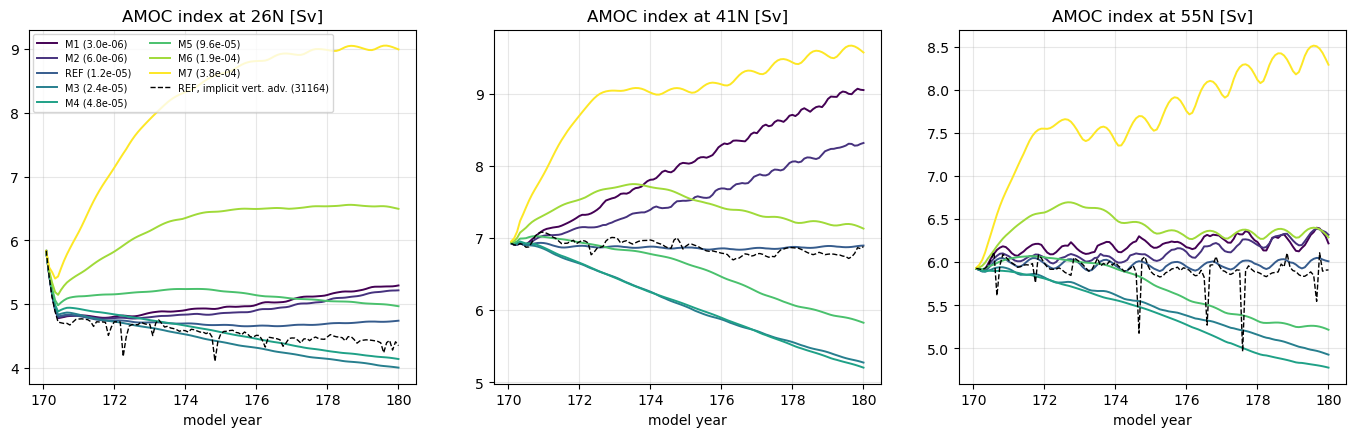

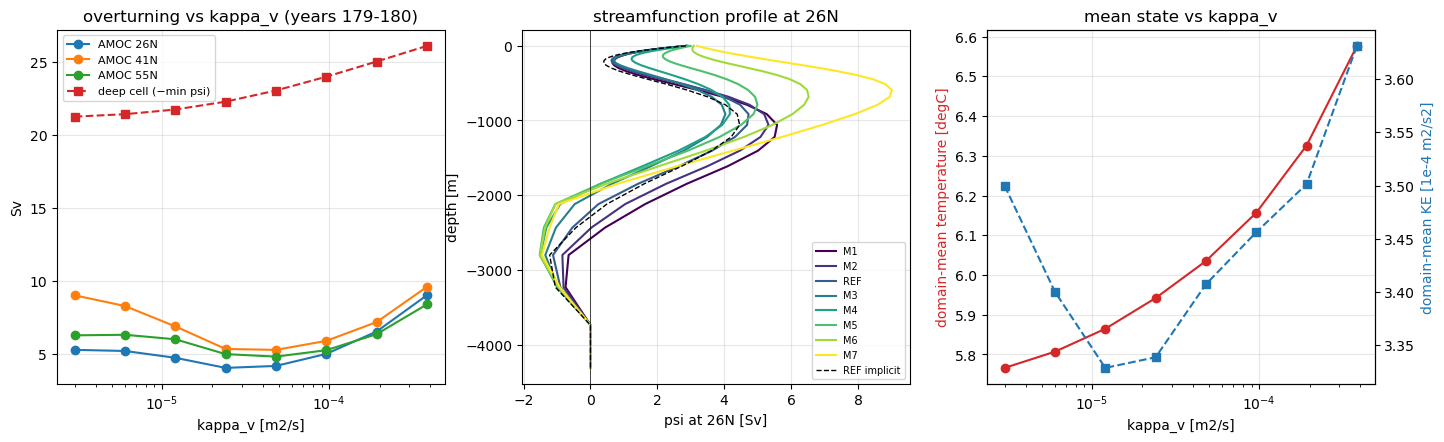

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
order = ['M1', 'M2', 'REF', 'M3', 'M4', 'M5', 'M6', 'M7']; cols = plt.cm.viridis(np.linspace(0, 1, len(order)))
for i, latp in enumerate((26, 41, 55)):
    for c_, lab in zip(cols, order): ax[i].plot(res[lab]['yrs'], res[lab]['amoc'][latp], color=c_, lw=1.4, label=f"{lab} ({KAPPA[lab]:.1e})")
    ax[i].plot(res['REF_implicit_31164']['yrs'], res['REF_implicit_31164']['amoc'][latp], 'k--', lw=1, label='REF, implicit vert. adv. (31164)')
    ax[i].set_title(f'AMOC index at {latp}N [Sv]'); ax[i].set_xlabel('model year'); ax[i].grid(alpha=0.3)
ax[0].legend(fontsize=7, ncol=2); fig.savefig(f'{FIG_DIR}/amoc_index_legs.png', dpi=110, bbox_inches='tight')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
k = np.array([KAPPA[m] for m in order]); ax[0].set_xscale('log')
for key, lab in (('amoc26', 'AMOC 26N'), ('amoc41', 'AMOC 41N'), ('amoc55', 'AMOC 55N')):
    ax[0].plot(k, [res[m]['summary'][key] for m in order], 'o-', label=lab)
ax[0].plot(k, [-res[m]['summary']['psi_min'] for m in order], 's--', label='deep cell (−min psi)'); ax[0].set_xlabel('kappa_v [m2/s]'); ax[0].set_ylabel('Sv'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3); ax[0].set_title('overturning vs kappa_v (years 179-180)')
j26 = int(np.abs(res['REF']['lat'] - 26).argmin())
for c_, lab in zip(cols, order): ax[1].plot(res[lab]['moc_end'][:, j26], res[lab]['z'], color=c_, label=lab)
ax[1].plot(res['REF_implicit_31164']['moc_end'][:, j26], res['REF_implicit_31164']['z'], 'k--', lw=1, label='REF implicit'); ax[1].axvline(0, color='k', lw=0.5)
ax[1].set_xlabel('psi at 26N [Sv]'); ax[1].set_ylabel('depth [m]'); ax[1].set_title('streamfunction profile at 26N'); ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3)
ax[2].set_xscale('log'); ax[2].plot(k, [res[m]['summary']['Tmean'] for m in order], 'o-', color='C3'); ax[2].set_xlabel('kappa_v [m2/s]'); ax[2].set_ylabel('domain-mean temperature [degC]', color='C3'); ax[2].grid(alpha=0.3)
ax2 = ax[2].twinx(); ax2.plot(k, [res[m]['summary']['ke_mean'] * 1e4 for m in order], 's--', color='C0'); ax2.set_ylabel('domain-mean KE [1e-4 m2/s2]', color='C0'); ax[2].set_title('mean state vs kappa_v')
fig.savefig(f'{FIG_DIR}/overturning_vs_kappa.png', dpi=110, bbox_inches='tight')

## Reading

- Every leg ran its ten years without incident under the corrected (explicit) vertical advection; the year-180 pickups exist for all eight.
- The overturning response to κ_v is not monotonic: from 0.25× to 2× the AMOC index at 26° N falls (5.3 → 4.0 Sv) as the thermocline deepens and the wind-driven upper cell weakens, then from 4× upward it rises steeply (4.2 → 9.0 Sv at 32×) as diapycnal upwelling takes over — the diffusive branch of the classical scaling. The deep cell and the domain-mean temperature increase monotonically with κ_v, the surface maximum temperature decreases, all as expected for stronger vertical mixing.
- The explicit vertical advection changes the reference state relative to the implicit run it replaces (31164) mostly at the equator: the tropical cell drops from 8.5 to 3.5 Sv, the AMOC at 26° N rises from 4.4 to 4.7 Sv, the mean temperature by 0.02 °C, the kinetic energy falls by 7 %.